In [52]:
import numpy as np
import matplotlib.pyplot as plt
import pyvisa as visa
import time

kHz = 1e3
MHz = 1e6
GHz = 1e9

In [172]:
ip = "TCPIP::192.168.0.27"

In [173]:
rm = visa.ResourceManager()
kna = rm.open_resource(ip)

In [177]:
kna.timeout =  10000
kna.write("*IDN?")
kna.write("SYST:PRES; *OPC?")

(18, <StatusCode.success: 0>)

In [185]:
active_channel = 1
n_traces = 1
active_trace = 1
s_ij = "S11"
meas_format = "COMP"  # SMIT REAL IMAG PHAS

kna.write(f":CALC{active_channel}:MEAS{active_channel}:PAR {s_ij};")
kna.write(f":CALC{active_channel}:MEAS{active_channel}:FORM {meas_format};")

(25, <StatusCode.success: 0>)

In [156]:
IF_bw = 2 * kHz
n_points = 1001

kna.write(f":SENS{active_channel}:SWE:POIN {n_points}")
kna.write(f":SENS{active_channel}:SWE:TYPE LIN")

kna.write(f":SENS{active_channel}:AVER ON")
kna.write(f":SENS{active_channel}:AVER:COUN 100")
kna.write(f":SENS{active_channel}:BWID {IF_bw}")

(20, <StatusCode.success: 0>)

In [133]:
f_center = 6.0 * GHz
f_span = 100 * MHz
x_data = np.linspace(f_center - f_span/2, f_center + f_span/2, n_points)
power_dBm = 0

kna.write(f":SENS{active_channel}:FREQ:CENT {f_center}")
kna.write(f":SENS{active_channel}:FREQ:SPAN {f_span}")
kna.write(f":SOUR{active_channel}:POW {power_dBm}")

(14, <StatusCode.success: 0>)

In [142]:
kna.write(":CALC1:MEAS1:DATA:FDAT?")
ydata_str = kna.read()
ydata_temp = ydata_str.split(",")
y_data = np.array([float(d) for d in ydata_temp])
y_data = y_data.reshape(n_points, 2)
y_data = y_data.transpose()

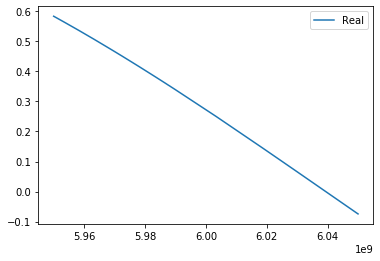

In [147]:
plt.plot(x_data,y_data[0], label = "Real")
plt.plot(x_data,y_data[1], label = "Imag")
plt.legend()

In [161]:
meas_format = "IMAG"  # SMIT REAL IMAG PHAS

kna.write(f":CALC{active_channel}:FORM {meas_format};")

(19, <StatusCode.success: 0>)

In [129]:
kna.write(":CALC1:MEAS1:DATA:FDAT?")
ydata_str = kna.read()
ydata_temp = ydata_str.split(",")

In [149]:
real, imag = y_data

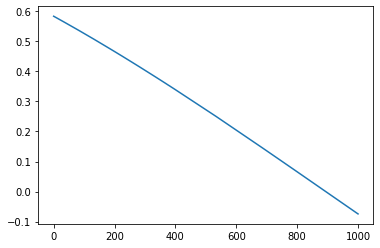

In [150]:
plt.plot(real)